<a href="https://colab.research.google.com/github/Allanlin001/CatUnet/blob/main/Animal_UNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%pylab inline
#Magic command specfic to IPython environments like Google Collab or Jupyter
# %pylab imports numpy and matplotlib and inline allows the plot to be shown directly in the notebook instead of another tab

Populating the interactive namespace from numpy and matplotlib


In [2]:
!pip install keras-unet

In [5]:
from keras_unet.models import custom_unet
#allows easy access to prebuilt u-net model

-----------------------------------------
keras-unet init: TF version is >= 2.0.0 - using `tf.keras` instead of `Keras`
-----------------------------------------


In [1]:

!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

--2026-04-03 18:41:14--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-03 18:41:15--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  21.1MB/s    in 38s     

2026-04-03 18:41:54 (20.1 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-04-03 18:41:54--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [18]:
import os
from PIL import Image

#extract the images
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

# stores the name of the images without jpg extension
names = sorted([f[:-4] for f in os.listdir('./images') if f.endswith('.jpg')])

# Will hold the processed images and masks
image_list = []
mask_list = []

for n in names:
    try:
        # Process image
        img_path = f'./images/{n}.jpg'
        img = Image.open(img_path).resize((300,300)).convert('RGB') # Ensure RGB
        img_array = np.array(img, dtype=np.float32) / 255.0

        if img_array.shape != (300, 300, 3):
            print(f"Warning: Image {n}.jpg has unexpected shape {img_array.shape}. Expected (300, 300, 3). Skipping.")
            continue # Skip this image if shape is wrong
        image_list.append(img_array)

        # Process mask
        mask_path = f'./annotations/trimaps/{n}.png'
        mask = Image.open(mask_path).resize((300,300))
        mask_array = (np.array(mask) == 1).astype(np.float32)

        if mask_array.shape != (300, 300):
            print(f"Warning: Mask {n}.png has unexpected shape {mask_array.shape}. Expected (300, 300). Skipping associated image.")
            # If mask shape is wrong, remove the last added image to keep lists synchronized
            image_list.pop()
            continue
        mask_list.append(mask_array)

    except Exception as e:
        print(f"Error processing file {n}: {e}. Skipping.")
        continue
#Convert to numpu arrays
images = np.array(image_list)
masks  = np.array(mask_list)

print(f"Loaded {len(image_list)} images and {len(mask_list)} masks.")
print(f"Images shape: {images.shape}, Masks shape: {masks.shape}")

Loaded 7390 images and 7390 masks.
Images shape: (7390, 300, 300, 3), Masks shape: (7390, 300, 300)


In [25]:
X_train = images[:190]
y_train = masks[:190]
#np.pad adds padding to the images
X_train = np.pad(X_train, ((0,0),(10,10),(10,10),(0,0))) # This padding assumes last dim exists, which is 3 for RGB
y_train = np.pad(y_train[..., None], ((0,0),(10,10),(10,10),(0,0))) # Add channel dim (1) for masks then pad

X_test = images[190:]
y_test = masks[190:]
X_test = np.pad(X_test, ((0,0),(10,10),(10,10),(0,0)))
y_test = np.pad(y_test[..., None], ((0,0),(10,10),(10,10),(0,0)))

In [20]:
model = custom_unet(
    input_shape=(320, 320, 3), # Change input_shape to 3 for RGB images
    dropout=0.2
)
model.compile(loss='binary_crossentropy')

In [26]:

#
# 3. TRAIN
#
from keras.callbacks import ModelCheckpoint, EarlyStopping

model_filename = 'segm_model_v3.h5'
callback_checkpoint = ModelCheckpoint(
    model_filename,
    verbose=1,
    monitor='val_loss',
    save_best_only=True,
)

callback_earlystopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=50,
                    callbacks=[callback_checkpoint, callback_earlystopping])

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 0.3436  
Epoch 1: val_loss improved from None to 0.61681, saving model to segm_model_v3.h5



Epoch 1: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - loss: 0.3313 - val_loss: 0.6168
Epoch 2/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3513
Epoch 2: val_loss did not improve from 0.61681
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.3514 - val_loss: 0.8114
Epoch 3/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3565
Epoch 3: val_loss did not improve from 0.61681
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3585 - val_loss: 2.0107
Epoch 4/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3897
Epoch 4: val_loss did not improve from 0.61681
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3590 - val_loss: 0.7272
Epoch 5/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3211
Epoch 5: val_loss did not improve from 0.61681
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3426 - val_loss: 0.7573
Epoch 6/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3222
Epoch 6: val_loss did not improve from 0.61681
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/s


Epoch 8: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.3187 - val_loss: 0.5684
Epoch 9/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2953
Epoch 9: val_loss did not improve from 0.56837
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.3231 - val_loss: 0.7459
Epoch 10/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2842
Epoch 10: val_loss did not improve from 0.56837
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3002 - val_loss: 1.0038
Epoch 11/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2858
Epoch 11: val_loss did not improve from 0.56837
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.2901 - val_loss: 0.8319
Epoch 12/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2875
Epoch 12: val_loss did not improve from 0.56837
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2839 - val_loss: 0.6679
Epoch 13/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2851
Epoch 13: val_loss did not improve from 0.56837
6/6 ━━━━━━━━━━━━━━━━━━━━


Epoch 15: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.2794 - val_loss: 0.4912
Epoch 16/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2766
Epoch 16: val_loss did not improve from 0.49125
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2737 - val_loss: 1.0387
Epoch 17/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2756
Epoch 17: val_loss improved from 0.49125 to 0.43314, saving model to segm_model_v3.h5



Epoch 17: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.2703 - val_loss: 0.4331
Epoch 18/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3010
Epoch 18: val_loss did not improve from 0.43314
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2731 - val_loss: 0.5452
Epoch 19/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2547
Epoch 19: val_loss did not improve from 0.43314
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2681 - val_loss: 1.5794
Epoch 20/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2738
Epoch 20: val_loss did not improve from 0.43314
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2637 - val_loss: 0.8405
Epoch 21/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2542
Epoch 21: val_loss did not improve from 0.43314
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2602 - val_loss: 1.3544
Epoch 22/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2763
Epoch 22: val_loss did not improve from 0.43314
6/6 ━━━━━━━━━━━━━━━━━

...


Epoch 37: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.2284 - val_loss: 0.3268
Epoch 38/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2157
Epoch 38: val_loss did not improve from 0.32677
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.2114 - val_loss: 0.3463
Epoch 39/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2193
Epoch 39: val_loss did not improve from 0.32677
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.2243 - val_loss: 0.6820
Epoch 40/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2431
Epoch 40: val_loss did not improve from 0.32677
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.2447 - val_loss: 0.3287
Epoch 41/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2386
Epoch 41: val_loss did not improve from 0.32677
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2413 - val_loss: 0.3478
Epoch 42/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1986
Epoch 42: val_loss improved from 0.32677 to 0.32051, saving model to 


Epoch 42: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.2110 - val_loss: 0.3205
Epoch 43/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2026
Epoch 43: val_loss did not improve from 0.32051
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2031 - val_loss: 0.4454
Epoch 44/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2049
Epoch 44: val_loss improved from 0.32051 to 0.31404, saving model to segm_model_v3.h5



Epoch 44: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.2128 - val_loss: 0.3140
Epoch 45/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2080
Epoch 45: val_loss did not improve from 0.31404
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.2168 - val_loss: 0.3190
Epoch 46/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1861
Epoch 46: val_loss improved from 0.31404 to 0.30647, saving model to segm_model_v3.h5



Epoch 46: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.2099 - val_loss: 0.3065
Epoch 47/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2183
Epoch 47: val_loss did not improve from 0.30647
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2098 - val_loss: 0.3298
Epoch 48/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2131
Epoch 48: val_loss improved from 0.30647 to 0.29850, saving model to segm_model_v3.h5



Epoch 48: finished saving model to segm_model_v3.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.2084 - val_loss: 0.2985
Epoch 49/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1956
Epoch 49: val_loss did not improve from 0.29850
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1959 - val_loss: 0.3459
Epoch 50/50
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1963
Epoch 50: val_loss did not improve from 0.29850
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.1957 - val_loss: 0.3433


In [22]:

#
# 4. PREDICT
#
y_pred = model.predict(X_test)

226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step


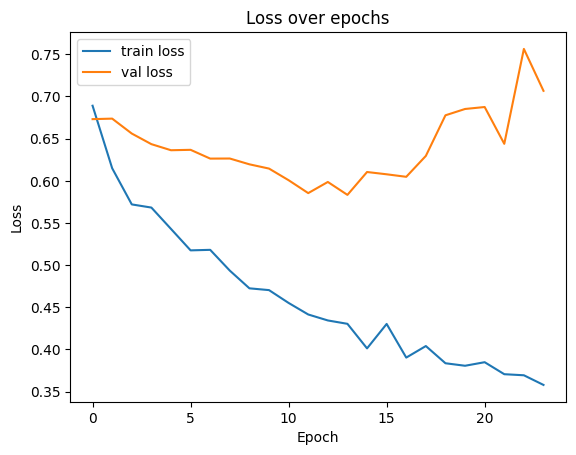

In [23]:

# LOSS PLOT
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

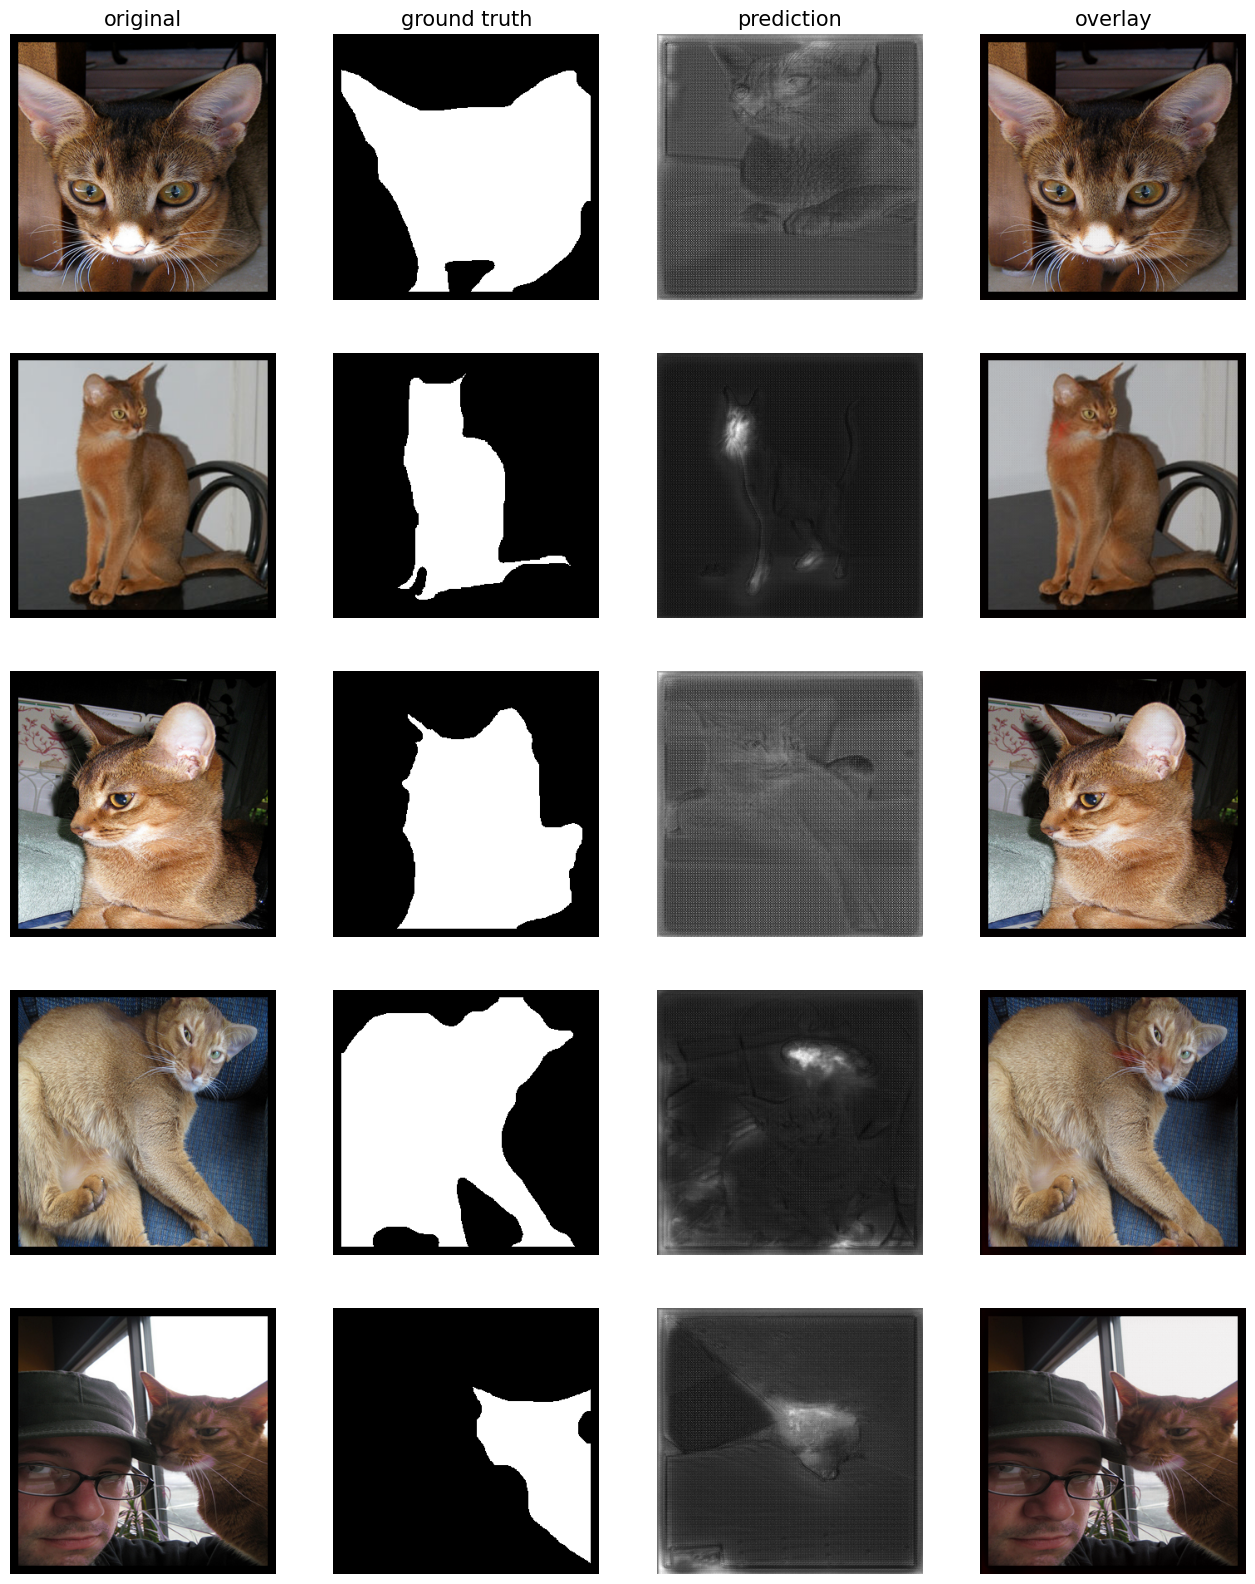

In [28]:

from keras_unet.utils import plot_imgs
plot_imgs(org_imgs=X_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=5)